In [1]:
import os
import shutil

# Clean previous clone if any (Kaggle session may persist)
if os.path.exists('trash-classification'):
    shutil.rmtree('trash-classification')

# Clone the project repo
!git clone https://github.com/wayofell/trash-classification.git

# Move into the repo so imports work
%cd trash-classification

# Show structure
!ls -la
!echo "---"
!ls -la src/

Cloning into 'trash-classification'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 29 (delta 8), reused 23 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 2.26 MiB | 31.75 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/kaggle/working/trash-classification
total 52
drwxr-xr-x 8 root root 4096 May 16 05:44 .
drwxr-xr-x 4 root root 4096 May 16 05:44 ..
drwxr-xr-x 3 root root 4096 May 16 05:44 data
drwxr-xr-x 2 root root 4096 May 16 05:44 experiments
drwxr-xr-x 8 root root 4096 May 16 05:44 .git
-rw-r--r-- 1 root root 5043 May 16 05:44 .gitignore
-rw-r--r-- 1 root root 1070 May 16 05:44 LICENSE
drwxr-xr-x 2 root root 4096 May 16 05:44 notebooks
-rw-r--r-- 1 root root 2753 May 16 05:44 README.md
drwxr-xr-x 2 root root 4096 May 16 05:44 report
-rw-r--r-- 1 root root  270 May 16 05:44 requirements.txt
drwxr-xr-x 2 root root 4096 May 16 05:44 src
---
total 20
drwxr-xr-x 

In [4]:
import sys

# Add current dir to path so 'src' becomes importable
sys.path.insert(0, '.')

from src.data import (
    load_dataset, get_class_weights, get_class_names, get_data_root,
    CLASS_NAMES, NUM_CLASSES, IMG_SIZE
)

print("Imports OK")
print(f"Data root: {get_data_root()}")
print(f"Classes: {CLASS_NAMES}")
print(f"Num classes: {NUM_CLASSES}")
print(f"Image size: {IMG_SIZE}")

Imports OK
Data root: /kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_256
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Num classes: 10
Image size: (224, 224)


In [6]:
import time

start = time.time()
train_ds, val_ds, test_ds, sizes = load_dataset(batch_size=32)
elapsed = time.time() - start

print(f"Dataset built in {elapsed:.2f}s\n")
print("Split sizes:")
for split, n in sizes.items():
    print(f"  {split:5s}: {n:>5d} samples")

total = sum(sizes.values())
print(f"  {'total':5s}: {total:>5d} samples")

Dataset built in 0.41s

Split sizes:
  train:  8593 samples
  val  :  1833 samples
  test :  1833 samples
  total: 12259 samples


In [8]:
import numpy as np
from collections import Counter

def count_labels(ds):
    """Iterate through dataset and count labels."""
    counter = Counter()
    for _, labels in ds:
        for lbl in labels.numpy():
            counter[int(lbl)] += 1
    return counter

print("Counting labels in each split...")
print("(this iterates through all data, takes ~30 seconds)\n")

train_counts = count_labels(train_ds)
val_counts = count_labels(val_ds)
test_counts = count_labels(test_ds)

# Build comparison table
print(f"{'class':12s} {'train':>7s} {'val':>6s} {'test':>6s}  "
      f"{'train%':>7s} {'val%':>7s} {'test%':>7s}")
print("-" * 70)

for idx, cls in enumerate(CLASS_NAMES):
    tr = train_counts[idx]
    vl = val_counts[idx]
    ts = test_counts[idx]
    tr_pct = 100 * tr / sum(train_counts.values())
    vl_pct = 100 * vl / sum(val_counts.values())
    ts_pct = 100 * ts / sum(test_counts.values())
    print(f"{cls:12s} {tr:>7d} {vl:>6d} {ts:>6d}  "
          f"{tr_pct:>6.2f}% {vl_pct:>6.2f}% {ts_pct:>6.2f}%")

Counting labels in each split...
(this iterates through all data, takes ~30 seconds)

class          train    val   test   train%    val%   test%
----------------------------------------------------------------------
battery          530    113    113    6.17%   6.16%   6.16%
biological       491    104    104    5.71%   5.67%   5.67%
cardboard        989    211    211   11.51%  11.51%  11.51%
clothes         1326    283    283   15.43%  15.44%  15.44%
glass           1216    260    260   14.15%  14.18%  14.18%
metal            652    139    139    7.59%   7.58%   7.58%
paper            936    200    200   10.89%  10.91%  10.91%
plastic         1119    239    239   13.02%  13.04%  13.04%
shoes           1015    217    217   11.81%  11.84%  11.84%
trash            319     67     67    3.71%   3.66%   3.66%


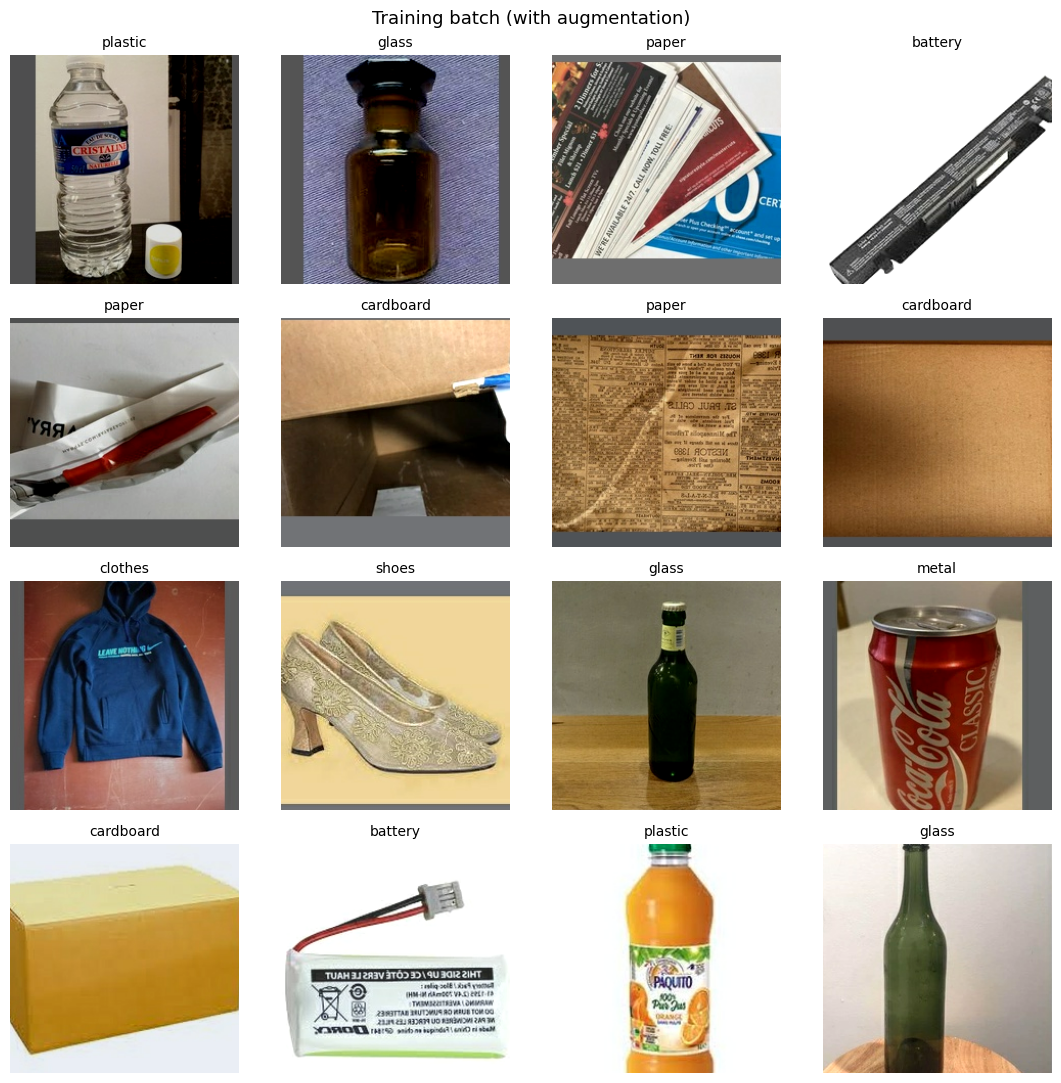


Batch info:
  Shape: (32, 224, 224, 3)
  Dtype: float32
  Value range: [0.0, 255.0]
  Mean: 142.5


In [11]:
import matplotlib.pyplot as plt

# Take one batch from training set
for images, labels in train_ds.take(1):
    images = images.numpy()
    labels = labels.numpy()
    break

# Display 16 images in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(11, 11))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        # Images are in [0, 255] float — clip and convert for display
        img = np.clip(images[i], 0, 255).astype(np.uint8)
        ax.imshow(img)
        ax.set_title(CLASS_NAMES[labels[i]], fontsize=10)
    ax.axis('off')

plt.suptitle('Training batch (with augmentation)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nBatch info:")
print(f"  Shape: {images.shape}")
print(f"  Dtype: {images.dtype}")
print(f"  Value range: [{images.min():.1f}, {images.max():.1f}]")
print(f"  Mean: {images.mean():.1f}")

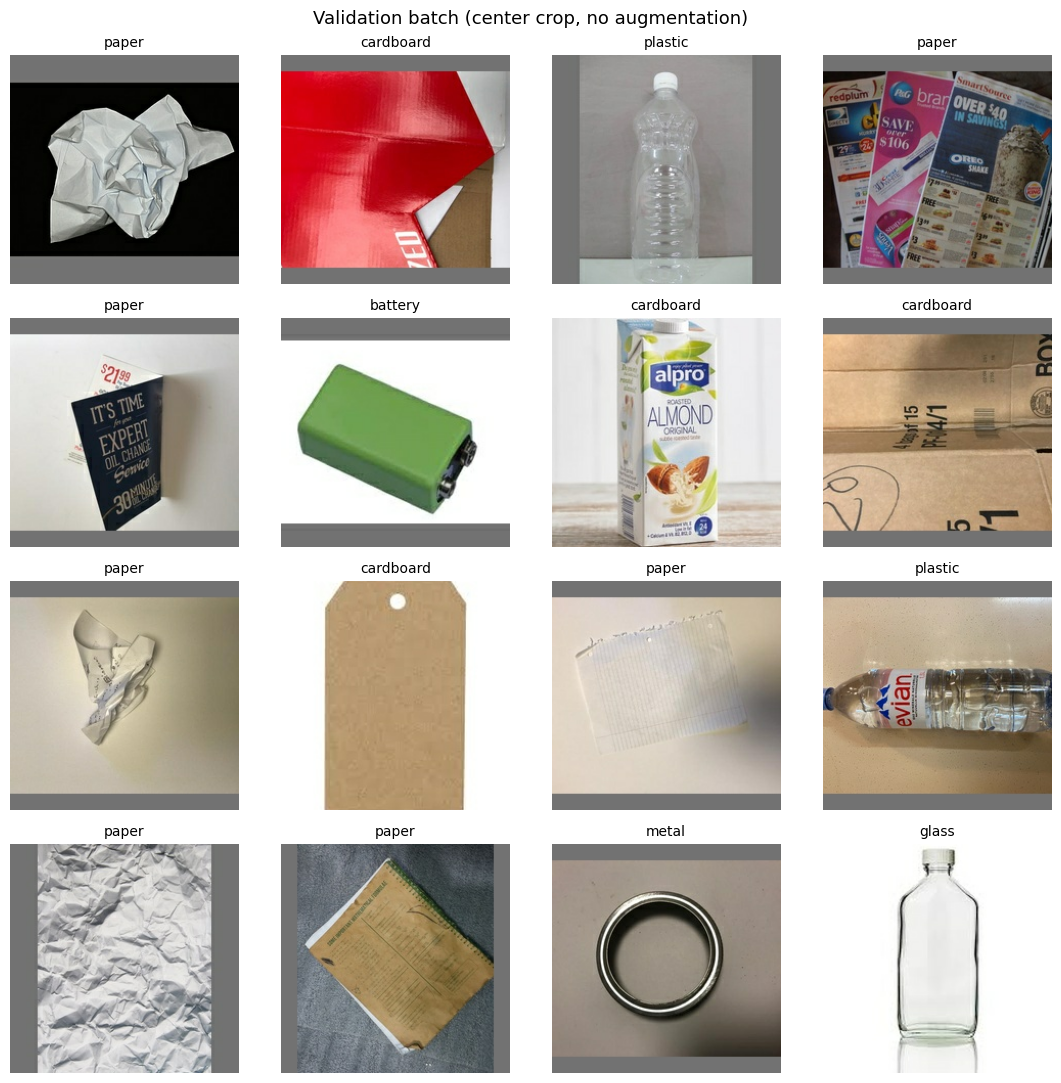

In [13]:
for images, labels in val_ds.take(1):
    images = images.numpy()
    labels = labels.numpy()
    break

fig, axes = plt.subplots(4, 4, figsize=(11, 11))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        img = np.clip(images[i], 0, 255).astype(np.uint8)
        ax.imshow(img)
        ax.set_title(CLASS_NAMES[labels[i]], fontsize=10)
    ax.axis('off')

plt.suptitle('Validation batch (center crop, no augmentation)', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
weights = get_class_weights()

print("Class weights (inverse frequency, normalized):\n")
print(f"{'class':12s} {'weight':>8s}  {'effect':<30s}")
print("-" * 60)

for idx, cls in enumerate(CLASS_NAMES):
    w = weights[idx]
    if w > 1.5:
        effect = "boosted (rare class)"
    elif w < 0.7:
        effect = "downweighted (common class)"
    else:
        effect = "neutral"
    print(f"{cls:12s} {w:>8.3f}  {effect:<30s}")

Class weights (inverse frequency, normalized):

class          weight  effect                        
------------------------------------------------------------
battery         1.622  boosted (rare class)          
biological      1.754  boosted (rare class)          
cardboard       0.869  neutral                       
clothes         0.648  downweighted (common class)   
glass           0.706  neutral                       
metal           1.318  neutral                       
paper           0.918  neutral                       
plastic         0.768  neutral                       
shoes           0.846  neutral                       
trash           2.706  boosted (rare class)          
